# Flowshop Example (Cyclic Workshop)

This notebook presents the application of (max,+) algebra to cyclic flowshop workshops, following the ScicosLab toolbox example.

## Flowshop Model

- **Parts** are carried on **pallets**. When tasks on a part are finished, the pallet starts another cycle with another part of the same class.
- Each part visits machines in sequence, never coming back to the same machine.
- For a given task, we can have several machines (a "class"). Machines visit parts in sequence.
- The flowshop is defined by a matrix describing resources and processing times.
- Each **row** corresponds to a machine class.
- Each **column** corresponds to a part class.
- Entries are **processing times**.
- If a part class doesn't need a machine class, the entry is $-\infty$ (`mp0` or `ε`).

In [1]:
push!(LOAD_PATH, pwd())
using MaxPlus, SparseArrays

## Data: Processing Times `PT`

Machines × Parts matrix in (max,+). Empty cells correspond to `mp0` (ε).

In [2]:
PT = MP.([
    2    3.9  0.95 1.1  0.7  1.4
    mp0  mp0  2    1.2  mp0  1.7
    3.7  mp0  2.2  mp0  6.4  mp0
    mp0  mp0  2    mp0  1    1
    1.7  3.1  3    mp0  1.3  mp0
    0.5  3.2  4.3  1.9  1.6  0.4
    1    1    1    1    1    1
    1.5  1.5  1.5  1.2  1.2  1.2
])

8×6 (max,+) dense matrix:
    2   3.9   0.95   1.1   0.7   1.4
    .     .      2   1.2     .   1.7
  3.7     .    2.2     .   6.4     .
    .     .      2     .     1     1
  1.7   3.1      3     .   1.3     .
  0.5   3.2    4.3   1.9   1.6   0.4
    1     1      1     1     1     1
  1.5   1.5    1.5   1.2   1.2   1.2


In [3]:
nmach, npiece = size(PT)
println("Number of machines: $nmach, Number of parts: $npiece")

Number of machines: 8, Number of parts: 6


### Number of Pallets/Machines per Class

- `nm[i]` = number of machines (or buffers) for machine class `i`
- `np[j]` = number of pallets for part class `j`

Here, simple periodic case with 1 everywhere:

In [4]:
nm = ones(Int, nmach)  # 1 machine per class
np = ones(Int, npiece) # 1 pallet per class

6-element Vector{Int64}:
 1
 1
 1
 1
 1
 1

## Graph (T, N) and Spectral Analysis

The function `flowshop_graph` builds sparse matrices `T` (times) and `N` (token counts) of the timed event graph associated with the flowshop.

In [5]:
T, N = flowshop_graph(PT, Float64.(nm), Float64.(np))
println("T: ", size(T), " non-zeros: ", nnz(T))
println("N: ", size(N), " non-zeros: ", nnz(N))

T: (65, 65) non-zeros: 102
N: (65, 65) non-zeros: 102


### Throughput Computation (Semi-Howard)

The Semi-Howard algorithm computes the eigenvalue (throughput) of the system. In (max,+), the eigenvalue represents the asymptotic cycle time.

In [6]:
r = semihoward(T, N)
λ = plustimes(r.eigenvalues[1])
println("Eigenvalue (cycle time): λ = $λ")

Eigenvalue (cycle time): λ = 16.95


## (max,+) Linear System

The function `flowshop` builds the implicit (max,+) linear system associated with the flowshop:

$$X(n) = D \otimes X(n) \oplus A \otimes X(n-1) \oplus B \otimes U(n)$$
$$Y(n) = C \otimes X(n)$$

In [7]:
s = flowshop(PT)
println("Flowshop system:")
println("  States: ", size(s.A, 1))
println("  Inputs: ", size(s.B, 2))
println("  Outputs: ", size(s.C, 1))

Flowshop system:
  States: 48
  Inputs: 14
  Outputs: 14


## The Shift Register `mpshift`

### Original Scilab Code

```scilab
fbm = shift(nm(1), 0)
for i = 1:nmach-1
    fbm = fbm | shift(nm(i), 0)
end
```

### Explanation

The function `shift(n, t)` (called `mpshift` in Julia) creates a (max,+) linear system representing a **shift register**:
- `n` = number of stages (delay)
- `t` = initial time of the first output

The `|` operator is the **diagonal composition** (parallel connection) of two systems.

The code builds `fbm` (feedback machines), which is the parallel composition of all machine shift registers. Each machine has `nm(i)` buffers, modeling the constraint that a machine can only process one part at a time.

### Julia Example

In [8]:
# Simple shift register: 2 stages, initial time 0
sh = mpshift(2, 0.0)
println("mpshift(2, 0):")
println("  Dimension A: ", size(sh.A))
display(sh)

mpshift(2, 0):
  Dimension A: (3, 3)


Implicit dynamic linear Max-Plus system:
  x(n) = D*x(n) + A*x(n-1) + B*u(n)
  y(n) = C*x(n)
  x(0) = x0

with:
D = 3×3 (max,+) dense matrix:
  .   .   .
  .   .   .
  .   .   .

A = 3×3 (max,+) dense matrix:
  .   0   .
  .   .   0
  .   .   .

B = 3×1 (max,+) dense matrix:
  .
  .
  0

C = 1×3 (max,+) dense matrix:
  0   .   .

x0 = 3×1 (max,+) dense matrix:
  .
  .
  .


In [9]:
# Building machine buffers (Scilab equivalent)
fbm = mpshift(nm[1], 0)
for i in 2:nmach
    fbm = fbm | mpshift(nm[i], 0)
end
println("Machine buffers fbm: dimension A = ", size(fbm.A))

# Building part buffers
fbp = mpshift(np[1], 0)
for i in 2:npiece
    fbp = fbp | mpshift(np[i], 0)
end
println("Part buffers fbp: dimension A = ", size(fbp.A))

Machine buffers fbm: dimension A = (16, 16)
Part buffers fbp: dimension A = (12, 12)


## Simulation with `flowshop_simu`

The function `flowshop_simu` encapsulates:
1. Building machine and part buffers (`mpshift` + `|`)
2. Feedback composition (`/`)
3. Conversion to explicit form (`explicit`)
4. Simulation (`simul`)
5. Subtracting periodic drift

### Input Convention

The matrix `u` follows the Scilab convention:
- **Rows** = inputs (nmach + npiece)
- **Columns** = time steps

In [10]:
nt = 100  # number of time steps
nio = nmach + npiece  # number of inputs
u = ones(Float64, nio, nt)
println("Inputs u: ", size(u), " (rows=inputs, columns=time)")

Inputs u: (14, 100) (rows=inputs, columns=time)


In [11]:
chi, y = flowshop_simu(s, nm, np, u)
println("Outputs y: ", size(y), " (rows=time, columns=outputs)")
println("Eigenvalue: ", chi.eigenvalues[1])

Outputs y: (100, 14) (rows=time, columns=outputs)
Eigenvalue: 16.950000000000003


## Plots

Outputs `y` are in Float64, with periodic drift already subtracted.

In [12]:
using Plots
Plots.default(size = (760, 400), legend = :outerright)

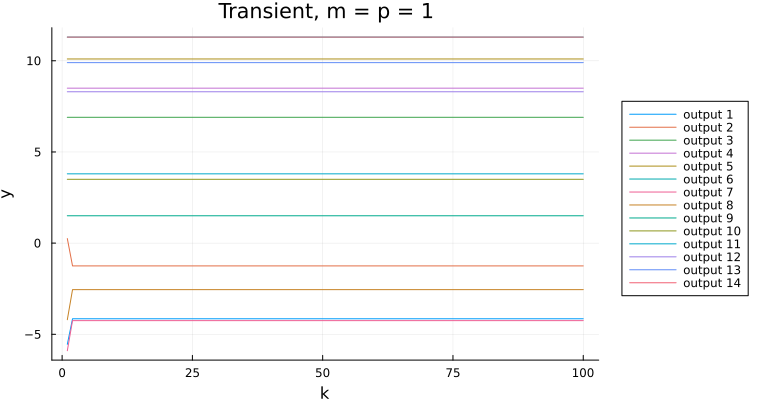

In [13]:
p = plot(title = "Transient, m = p = 1", xlabel = "k", ylabel = "y")
for j in 1:min(14, size(y, 2))
    plot!(p, 1:size(y, 1), y[:, j]; label = "output $j")
end
display(p)

### Case with More Buffers (m = p = 3)

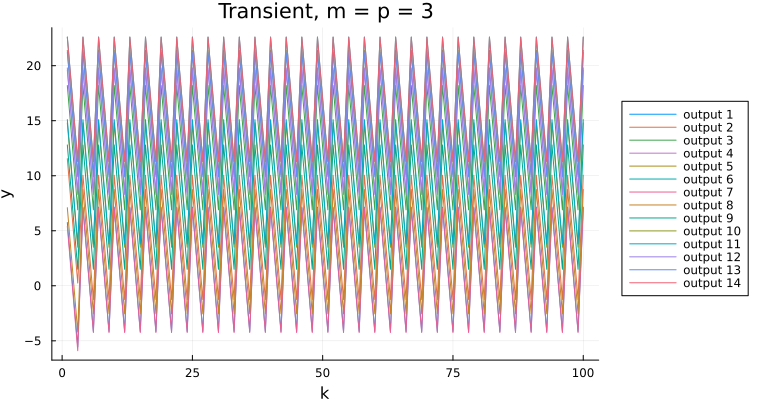

In [14]:
nm3 = fill(3, nmach)
np3 = fill(3, npiece)
_, y3 = flowshop_simu(s, nm3, np3, u)

p2 = plot(title = "Transient, m = p = 3", xlabel = "k", ylabel = "y")
for j in 1:min(14, size(y3, 2))
    plot!(p2, 1:size(y3, 1), y3[:, j]; label = "output $j")
end
display(p2)

## Function Summary

| Julia Function | Scilab Equivalent | Description |
|----------------|-------------------|-------------|
| `mpshift(n, t)` | `shift(n, t)` | Shift register with n stages |
| `S1 \| S2` | `S1 \| S2` | Diagonal composition (parallel) |
| `S1 / S2` | `S1 /. S2` | Feedback composition |
| `explicit(S)` | `explicit(S)` | Convert implicit → explicit form |
| `simul(S, u, history)` | `simul(S, u)` | System simulation |
| `flowshop(PT)` | `flowshop(PT)` | Build flowshop system |
| `flowshop_graph(PT, nm, np)` | `flowshop_graph(PT, nm, np)` | Flowshop (T, N) graph |
| `flowshop_simu(s, nm, np, u)` | (manual script) | Encapsulated full simulation |
| `semihoward(T, N)` | `semihoward(T, N)` | Semi-Howard algorithm |